This notebook evaluates the supervised XGBoost model and the unsupervised Isolation Forest model using actual financial cost rather than abstract metrics like AUPRC or accuracy. A missed fraud is costed at the real transaction amount lost; a false alarm is costed at a fixed operational review cost. This translates model performance into a business-relevant outcome: how much money each approach would actually cost if deployed.

Load both models and both test predictions

In [1]:
import pandas as pd
import joblib

test_df = pd.read_csv("../data/processed/test.csv")
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]
amounts_test = test_df["Amount"]

xgb_model = joblib.load("../artifacts/xgboost_fraud_model.pkl")
iso_model = joblib.load("../artifacts/isolation_forest_model.pkl")

y_pred_xgb = xgb_model.predict(X_test)

raw_iso_pred = iso_model.predict(X_test)
y_pred_iso = pd.Series(raw_iso_pred).map({1: 0, -1: 1}).values

print("XGBoost predictions:", y_pred_xgb[:10])
print("Isolation Forest predictions:", y_pred_iso[:10])
print("Sample amounts:", amounts_test.values[:10])

C:\Users\samir\AppData\Local\Temp\ipykernel_18032\3084469828.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


XGBoost predictions: [0 0 0 0 0 0 0 0 0 0]
Isolation Forest predictions: [0 0 0 0 0 0 0 0 0 0]
Sample amounts: [ 11.5    1.94  91.28 228.     1.41  20.99 234.9   21.44  20.    59.82]


Both saved models (XGBoost and Isolation Forest) loaded successfully from artifacts/ and ran predictions on the same test set without retraining.
Predictions for both models converted to the same 0/1 format, consistent with every prior notebook.
Real transaction amounts loaded alongside predictions — this is the actual financial data needed to compute cost, not a placeholder.

Cost-sensitive evaluation

In [2]:
import sys
sys.path.append("../src")
from utils import calculate_fraud_cost

xgb_cost = calculate_fraud_cost(y_test.values, y_pred_xgb, amounts_test.values)
iso_cost = calculate_fraud_cost(y_test.values, y_pred_iso, amounts_test.values)

print("XGBoost cost breakdown:", xgb_cost)
print("Isolation Forest cost breakdown:", iso_cost)

XGBoost cost breakdown: {'total_cost': 4624.049999999999, 'false_negative_cost': 3804.0499999999997, 'false_positive_cost': 70, 'true_positive_cost': 750}
Isolation Forest cost breakdown: {'total_cost': 13976.32, 'false_negative_cost': 13086.32, 'false_positive_cost': 710, 'true_positive_cost': 180}


XGBoost's total estimated cost: $4,624.05, driven mainly by $3,804.05 in missed fraud value.
Isolation Forest's total estimated cost: $13,976.32, roughly 3 times higher, driven by $13,086.32 in missed fraud value.
This confirms, in real financial terms, what AUPRC and the confusion matrices already suggested: XGBoost is the substantially better model for this problem. The cost-sensitive lens makes the practical stakes concrete rather than abstract.
This calculation depends on an assumed $10 review cost per flagged transaction — a stated modeling assumption, not a verified real-world figure, and should be labeled as such wherever this result is reported.

Bar chart comparing both models' costs

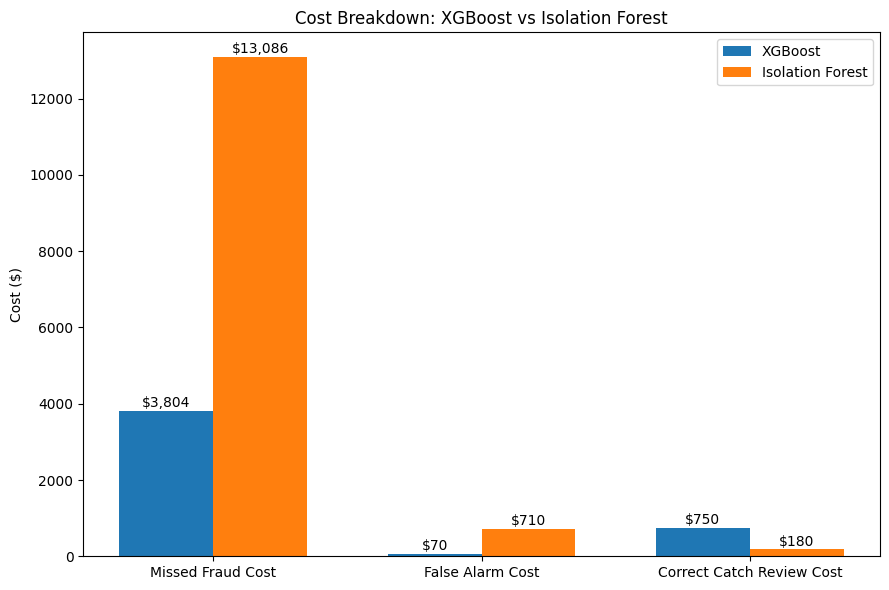

In [3]:
import matplotlib.pyplot as plt

labels = ["Missed Fraud Cost", "False Alarm Cost", "Correct Catch Review Cost"]
xgb_values = [xgb_cost["false_negative_cost"], xgb_cost["false_positive_cost"], xgb_cost["true_positive_cost"]]
iso_values = [iso_cost["false_negative_cost"], iso_cost["false_positive_cost"], iso_cost["true_positive_cost"]]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar([i - width/2 for i in x], xgb_values, width, label="XGBoost")
ax.bar([i + width/2 for i in x], iso_values, width, label="Isolation Forest")

ax.set_ylabel("Cost ($)")
ax.set_title("Cost Breakdown: XGBoost vs Isolation Forest")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i, v in enumerate(xgb_values):
    ax.text(i - width/2, v + 100, f"${v:,.0f}", ha="center")
for i, v in enumerate(iso_values):
    ax.text(i + width/2, v + 100, f"${v:,.0f}", ha="center")

plt.tight_layout()
plt.show()

Visual confirmation that missed fraud cost is the dominant driver of the total cost gap between the two models — Isolation Forest's missed fraud cost ($13,086) is over 3 times XGBoost's ($3,804).
False alarm cost is small for both models in absolute dollars, but Isolation Forest's is still 10 times higher than XGBoost's ($710 vs $70).
XGBoost's "correct catch review cost" being higher than Isolation Forest's ($750 vs $180) is not a weakness — it reflects XGBoost catching far more real fraud (75 vs 18), so it naturally accumulates more review cost on legitimate catches.
Overall, the chart makes the case visually and immediately clear: nearly the entire cost advantage of XGBoost comes from missing far less real fraud, not from avoiding false alarms.

Under a cost model assigning missed fraud its real transaction value and a flat $10 review cost per flagged transaction, XGBoost's total cost on the test set was $4,624.05, compared to Isolation Forest's $13,976.32 — nearly 3 times higher. The gap is driven almost entirely by missed fraud value: XGBoost missed $3,804.05 in fraud, while Isolation Forest missed $13,086.32. This confirms, in concrete financial terms, that the supervised model is substantially more valuable for this problem when labeled data is available. The $10 review cost is a stated modeling assumption rather than a verified industry figure, so the exact dollar totals should be read as estimates; however, the relative comparison between the two models holds regardless of the specific review cost chosen, since it is driven primarily by the difference in missed fraud value, not the review cost itself.

